In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [10]:
df = pd.read_csv("car_purchasing.csv", encoding='ISO-8859-1')  # or encoding='latin1'
print(df.head())

     customer name                                    customer e-mail  \
0    Martina Avila  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
1    Harlan Barnes                                eu.dolor@diam.co.uk   
2  Naomi Rodriquez  vulputate.mauris.sagittis@ametconsectetueradip...   
3  Jade Cunningham                            malesuada@dignissim.com   
4     Cedric Leach     felis.ullamcorper.viverra@egetmollislectus.net   

        country  gender        age  annual Salary  credit card debt  \
0      Bulgaria       0  41.851720    62812.09301      11609.380910   
1        Belize       0  40.870623    66646.89292       9572.957136   
2       Algeria       1  43.152897    53798.55112      11160.355060   
3  Cook Islands       1  58.271369    79370.03798      14426.164850   
4        Brazil       1  57.313749    59729.15130       5358.712177   

     net worth  car purchase amount  
0  238961.2505          35321.45877  
1  530973.9078          45115.52566  
2  638467.1773      

In [11]:
df = df.drop(columns=['customer name', 'customer e-mail'])


In [12]:
# Encode gender
le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])  # Male=1, Female=0

# Encode country (optional - or use OneHotEncoder if multiple countries exist)
le_country = LabelEncoder()
df['country'] = le_country.fit_transform(df['country'])


In [13]:
X = df.drop('car purchase amount', axis=1)
y = df['car purchase amount']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


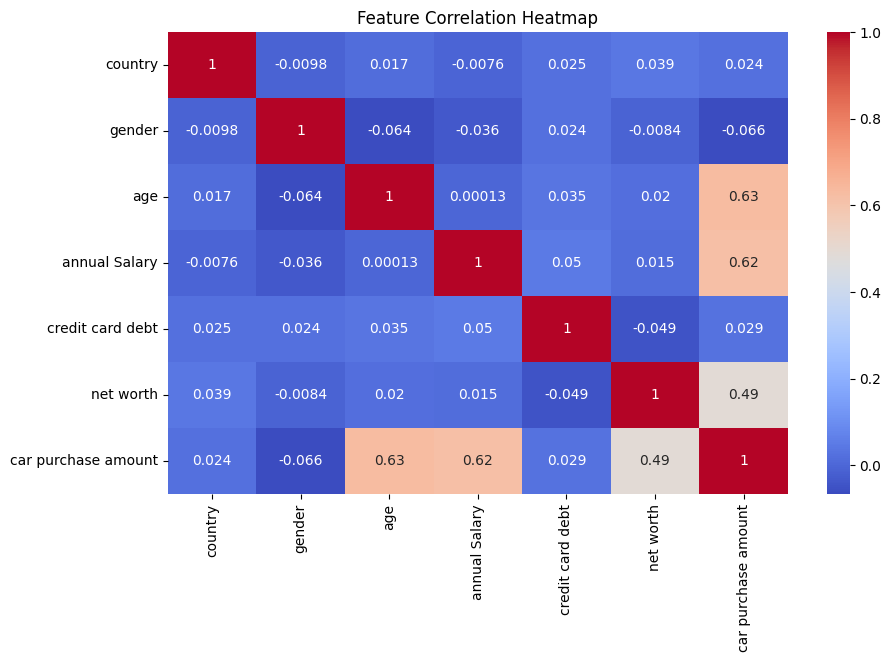

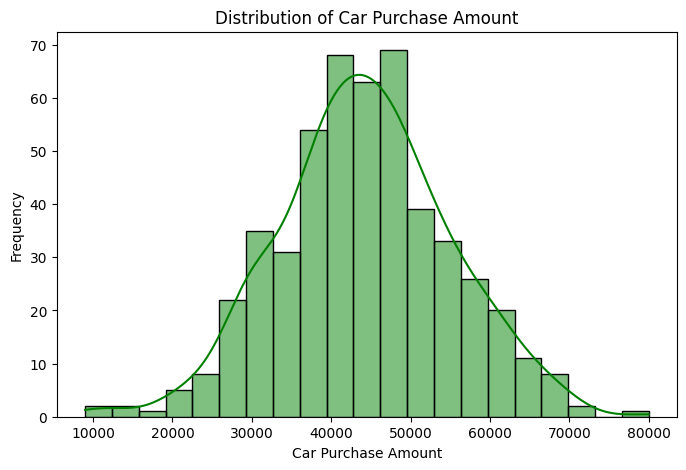

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of car purchase amount
plt.figure(figsize=(8,5))
sns.histplot(df['car purchase amount'], kde=True, color='green')
plt.title("Distribution of Car Purchase Amount")
plt.xlabel("Car Purchase Amount")
plt.ylabel("Frequency")
plt.show()


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [18]:
# Predict on test data
y_pred = model.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


Mean Squared Error: 2.1001405254789174
R-squared Score: 0.9999999805494205


In [19]:
import joblib

# Save model
joblib.dump(model, 'sales_prediction_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save encoders
joblib.dump(le_gender, 'gender_encoder.pkl')
joblib.dump(le_country, 'country_encoder.pkl')


['country_encoder.pkl']

In [21]:
# save_encoders.py
import joblib
from sklearn.preprocessing import LabelEncoder

# Define all possible classes
genders = ['Male', 'Female']
countries = ['USA', 'India', 'UK', 'Canada', 'Germany']  # Update as per your dataset

# Gender encoder
gender_encoder = LabelEncoder()
gender_encoder.fit(genders)
joblib.dump(gender_encoder, 'gender_encoder.pkl')

# Country encoder
country_encoder = LabelEncoder()
country_encoder.fit(countries)
joblib.dump(country_encoder, 'country_encoder.pkl')

print("Encoders saved successfully.")


Encoders saved successfully.
